In [8]:
df_flights = spark.read.csv(
    "Flights.csv",
    header=True,
    inferSchema=True
)

df_bookings = spark.read.csv(
    "bookings.csv",
    header=True,
    inferSchema=True
)

df_pref = spark.read.option("multiline", "true").json(
    "passenger_preferences.json"
)
df_pref_flat = df_pref.select(
    "passenger_name",
    "meal",
    "seat",
    "extra_baggage"
)

**Exploratory Data Analysis**

In [47]:
from pyspark.sql.functions import *
import matplotlib.pyplot as plt

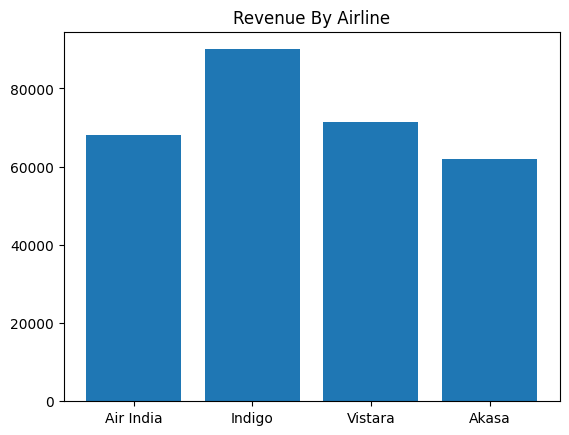

In [ ]:
# Revenue by Airline
revenue_airline = (
    df_bookings.join(df_flights,"flight_id")
    .groupBy("airline")
    .agg(sum("ticket_price").alias("Revenue"))
)

pdf = revenue_airline.toPandas()

plt.bar(pdf["airline"],pdf["Revenue"])
plt.title("Revenue By Airline")
plt.show()

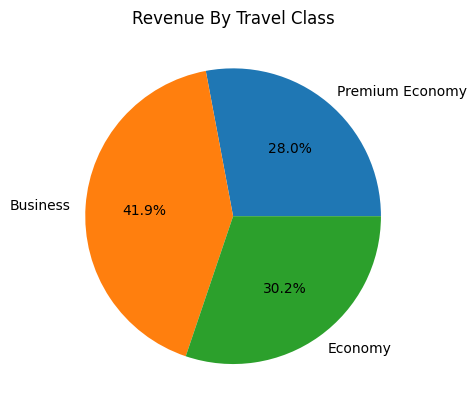

In [ ]:
# Revenue By Travel Class
travel_class = (
    df_bookings.groupBy("travel_class")
    .agg(sum("ticket_price").alias("Revenue"))
)

pdf = travel_class.toPandas()

plt.pie(
    pdf["Revenue"],
    labels=pdf["travel_class"],
    autopct="%1.1f%%"
)
plt.title("Revenue By Travel Class")
plt.show()

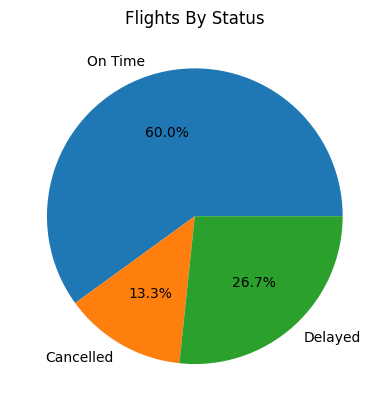

In [ ]:
# Flights By Status
status_df = df_flights.groupBy("status").count()

pdf = status_df.toPandas()

plt.pie(
    pdf["count"],
    labels=pdf["status"],
    autopct="%1.1f%%"
)

plt.title("Flights By Status")
plt.show()

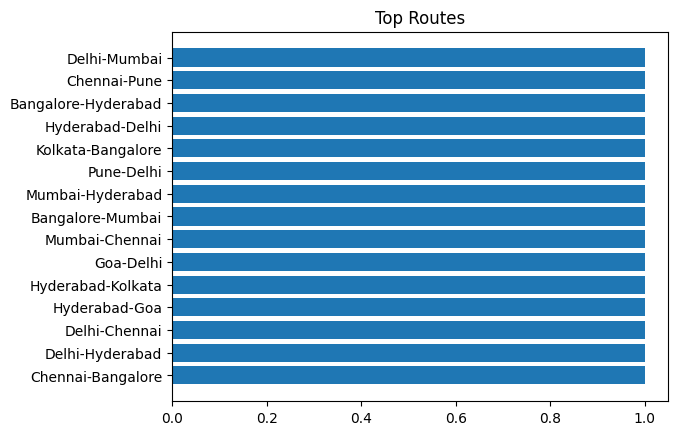

In [ ]:
# Top Routes
routes = (
    df_flights.groupBy(
        "from_city",
        "to_city"
    )
    .count()
)

pdf = routes.toPandas()

plt.barh(
    pdf["from_city"]+"-"+pdf["to_city"],
    pdf["count"]
)

plt.title("Top Routes")
plt.show()

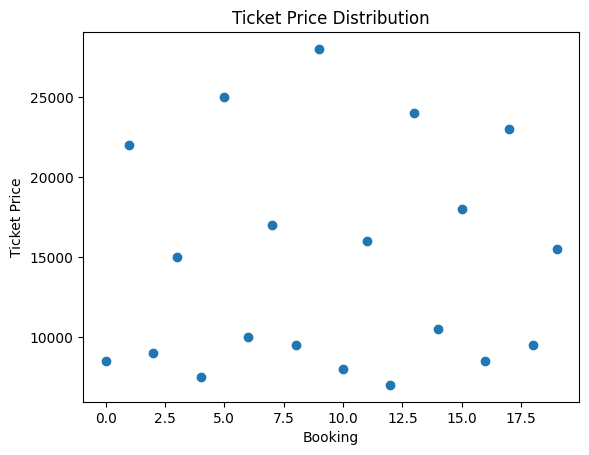

In [ ]:
# Ticket Price Distribution
pdf = df_bookings.toPandas()

plt.scatter(
    pdf.index,
    pdf["ticket_price"]
)

plt.title("Ticket Price Distribution")
plt.xlabel("Booking")
plt.ylabel("Ticket Price")

plt.show()

**Transformations**

In [48]:
# Revenue Column
df_bookings = df_bookings.withColumn(
    "revenue",
    col("ticket_price")
)

In [ ]:
# Price Band
df_bookings = df_bookings.withColumn(
    "price_band",
    when(col("ticket_price") > 20000,"Premium")
    .when(col("ticket_price") > 10000,"Standard")
    .otherwise("Budget")
)

In [55]:
# Delay Flag
df_flights = df_flights.withColumn(
    "delay_flag",
    when(col("status")=="Delayed","Yes")
    .otherwise("No")
)

In [54]:
# verify
df_bookings.show()
df_flights.show()

+----------+---------+--------------+---------------+------------+------------+-------+
|booking_id|flight_id|passenger_name|   travel_class|ticket_price|booking_date|revenue|
+----------+---------+--------------+---------------+------------+------------+-------+
|     B1001|     F101|  Rahul Sharma|        Economy|        8500|  2026-06-01|   8500|
|     B1002|     F101|   Priya Reddy|       Business|       22000|  2026-06-01|  22000|
|     B1003|     F102|    Amit Kumar|        Economy|        9000|  2026-06-02|   9000|
|     B1004|     F103|   Sneha Patel|Premium Economy|       15000|  2026-06-02|  15000|
|     B1005|     F104|    Farhan Ali|        Economy|        7500|  2026-06-03|   7500|
|     B1006|     F105|    Neha Singh|       Business|       25000|  2026-06-03|  25000|
|     B1007|     F106|   Arjun Verma|        Economy|       10000|  2026-06-04|  10000|
|     B1008|     F107|    Meera Nair|Premium Economy|       17000|  2026-06-04|  17000|
|     B1009|     F108|     Kiran

**Joins**

In [57]:
# Complete Passenger Journey Dataset
journey_df = (
    df_bookings
    .join(df_flights,"flight_id","left")
    .join(df_pref_flat,"passenger_name","left")
)

journey_df.show()

+--------------+---------+----------+---------------+------------+------------+-------+---------+---------+---------+--------+---------+----------+-------+------+-------------+
|passenger_name|flight_id|booking_id|   travel_class|ticket_price|booking_date|revenue|  airline|from_city|  to_city|duration|   status|delay_flag|   meal|  seat|extra_baggage|
+--------------+---------+----------+---------------+------------+------------+-------+---------+---------+---------+--------+---------+----------+-------+------+-------------+
|  Rahul Sharma|     F101|     B1001|        Economy|        8500|  2026-06-01|   8500|   Indigo|Hyderabad|    Delhi|     140|  On Time|        No|    Veg|Window|         true|
|   Priya Reddy|     F101|     B1002|       Business|       22000|  2026-06-01|  22000|   Indigo|Hyderabad|    Delhi|     140|  On Time|        No|Non-Veg| Aisle|        false|
|    Amit Kumar|     F102|     B1003|        Economy|        9000|  2026-06-02|   9000|Air India|   Mumbai|  Chenna

**Spark SQL**

In [58]:
df_flights.createOrReplaceTempView("flights")
df_bookings.createOrReplaceTempView("bookings")
journey_df.createOrReplaceTempView("journey")

In [ ]:
# Revenue by airline
spark.sql("""SELECT airline, SUM(ticket_price) AS revenue FROM journey
GROUP BY airline
ORDER BY revenue DESC;""").show()

+---------+-------+
|  airline|revenue|
+---------+-------+
|   Indigo|  90000|
|  Vistara|  71500|
|Air India|  68000|
|    Akasa|  62000|
+---------+-------+



In [ ]:
# Revenue by route
spark.sql("""SELECT from_city,to_city,SUM(ticket_price) AS revenue FROM journey
GROUP BY from_city,to_city
ORDER BY revenue DESC;""").show()

+---------+---------+-------+
|from_city|  to_city|revenue|
+---------+---------+-------+
|Hyderabad|    Delhi|  39000|
|Bangalore|Hyderabad|  38000|
|    Delhi|  Chennai|  28000|
|Hyderabad|  Kolkata|  26500|
|  Chennai|Bangalore|  25000|
|  Chennai|     Pune|  24000|
|Bangalore|   Mumbai|  23500|
|    Delhi|Hyderabad|  18000|
|Hyderabad|      Goa|  16000|
|  Kolkata|Bangalore|  10500|
|     Pune|    Delhi|  10000|
|   Mumbai|Hyderabad|   9500|
|   Mumbai|  Chennai|   9000|
|    Delhi|   Mumbai|   7500|
|      Goa|    Delhi|   7000|
+---------+---------+-------+



In [ ]:
# Average ticket price
spark.sql("""SELECT AVG(ticket_price) AS avg_ticket_price FROM bookings;""").show()

+----------------+
|avg_ticket_price|
+----------------+
|         14575.0|
+----------------+



In [ ]:
# Most popular destination
spark.sql("""SELECT to_city, COUNT(*) AS total_bookings FROM journey
GROUP BY to_city
ORDER BY total_bookings DESC;""").show()

+---------+--------------+
|  to_city|total_bookings|
+---------+--------------+
|    Delhi|             5|
|Hyderabad|             4|
|   Mumbai|             3|
|Bangalore|             2|
|  Chennai|             2|
|  Kolkata|             2|
|      Goa|             1|
|     Pune|             1|
+---------+--------------+



**Window Functions**

In [ ]:
from pyspark.sql.window import Window

In [ ]:
# Top 3 Revenue Flights
flight_rev = (
    journey_df.groupBy("flight_id")
    .agg(sum("ticket_price").alias("Revenue"))
)

window_spec = Window.orderBy(desc("Revenue"))

top_flights = flight_rev.withColumn(
    "Rank",
    rank().over(window_spec)
)

top_flights.filter("Rank<=3").show()

+---------+-------+----+
|flight_id|Revenue|Rank|
+---------+-------+----+
|     F101|  39000|   1|
|     F103|  38000|   2|
|     F109|  28000|   3|
+---------+-------+----+



In [ ]:
# Top routes by airline
route_df = (
    journey_df.groupBy("airline","from_city","to_city")
    .agg(sum("ticket_price").alias("Revenue"))
)

window_spec = Window.partitionBy("airline").orderBy(desc("Revenue"))

route_df.withColumn("Rank",
    rank().over(window_spec)
).show()

+---------+---------+---------+-------+----+
|  airline|from_city|  to_city|Revenue|Rank|
+---------+---------+---------+-------+----+
|Air India|  Chennai|Bangalore|  25000|   1|
|Air India|Bangalore|   Mumbai|  23500|   2|
|Air India|  Kolkata|Bangalore|  10500|   3|
|Air India|   Mumbai|  Chennai|   9000|   4|
|    Akasa|    Delhi|  Chennai|  28000|   1|
|    Akasa|  Chennai|     Pune|  24000|   2|
|    Akasa|     Pune|    Delhi|  10000|   3|
|   Indigo|Hyderabad|    Delhi|  39000|   1|
|   Indigo|    Delhi|Hyderabad|  18000|   2|
|   Indigo|Hyderabad|      Goa|  16000|   3|
|   Indigo|   Mumbai|Hyderabad|   9500|   4|
|   Indigo|    Delhi|   Mumbai|   7500|   5|
|  Vistara|Bangalore|Hyderabad|  38000|   1|
|  Vistara|Hyderabad|  Kolkata|  26500|   2|
|  Vistara|      Goa|    Delhi|   7000|   3|
+---------+---------+---------+-------+----+



In [ ]:
# Running revenue
window_spec = Window.orderBy("booking_date")

running_df = df_bookings.withColumn(
    "Running_Revenue",
    sum("ticket_price").over(window_spec)
)

running_df.show()

+----------+---------+--------------+---------------+------------+------------+-------+----------+---------------+
|booking_id|flight_id|passenger_name|   travel_class|ticket_price|booking_date|revenue|price_band|Running_Revenue|
+----------+---------+--------------+---------------+------------+------------+-------+----------+---------------+
|     B1001|     F101|  Rahul Sharma|        Economy|        8500|  2026-06-01|   8500|    Budget|          30500|
|     B1002|     F101|   Priya Reddy|       Business|       22000|  2026-06-01|  22000|   Premium|          30500|
|     B1003|     F102|    Amit Kumar|        Economy|        9000|  2026-06-02|   9000|    Budget|          54500|
|     B1004|     F103|   Sneha Patel|Premium Economy|       15000|  2026-06-02|  15000|  Standard|          54500|
|     B1005|     F104|    Farhan Ali|        Economy|        7500|  2026-06-03|   7500|    Budget|          87000|
|     B1006|     F105|    Neha Singh|       Business|       25000|  2026-06-03| 

In [ ]:
# Rank airlines
airline_rev = (
    journey_df.groupBy("airline")
    .agg(sum("ticket_price").alias("Revenue"))
)

window_spec = Window.orderBy(desc("Revenue"))

airline_rev.withColumn(
    "Rank",
    rank().over(window_spec)
).show()

+---------+-------+----+
|  airline|Revenue|Rank|
+---------+-------+----+
|   Indigo|  90000|   1|
|  Vistara|  71500|   2|
|Air India|  68000|   3|
|    Akasa|  62000|   4|
+---------+-------+----+



In [ ]:
# Dense Rank destinations
dest_df = (
    journey_df.groupBy("to_city")
    .count()
)

window_spec = Window.orderBy(desc("count"))

dest_df.withColumn(
    "Dense_Rank",
    dense_rank().over(window_spec)
).show()

+---------+-----+----------+
|  to_city|count|Dense_Rank|
+---------+-----+----------+
|    Delhi|    5|         1|
|Hyderabad|    4|         2|
|   Mumbai|    3|         3|
|Bangalore|    2|         4|
|  Chennai|    2|         4|
|  Kolkata|    2|         4|
|      Goa|    1|         5|
|     Pune|    1|         5|
+---------+-----+----------+



**Delta Lake**

In [ ]:
# Method 1
journey_df.write \
.format("delta") \
.mode("overwrite") \
.save("/delta/booking_master")

In [ ]:
# Method 2
journey_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("booking_master")

In [ ]:
# Method 3
spark.sql("""
CREATE TABLE booking_master_sql
USING DELTA
AS
SELECT *
FROM journey;
""")

DataFrame[]

**Incremental Load**

In [11]:
# Day 1
day1_data = [
("B1001","F101","Rahul Sharma","Economy",8500,"2026-06-01"),
("B1002","F101","Priya Reddy","Business",22000,"2026-06-01"),
("B1003","F102","Amit Kumar","Economy",9000,"2026-06-02"),
("B1004","F103","Sneha Patel","Premium Economy",15000,"2026-06-02"),
("B1005","F104","Farhan Ali","Economy",7500,"2026-06-03"),
("B1006","F105","Neha Singh","Business",25000,"2026-06-03"),
("B1007","F106","Arjun Verma","Economy",10000,"2026-06-04"),
("B1008","F107","Meera Nair","Premium Economy",17000,"2026-06-04"),
("B1009","F108","Kiran Rao","Economy",9500,"2026-06-05"),
("B1010","F109","Nisha Reddy","Business",28000,"2026-06-05"),
("B1011","F110","David Thomas","Economy",8000,"2026-06-06"),
("B1012","F111","Ayesha Khan","Premium Economy",16000,"2026-06-06"),
("B1013","F112","Rohit Sharma","Economy",7000,"2026-06-07"),
("B1014","F113","Pooja Mehta","Business",24000,"2026-06-07"),
("B1015","F114","Sanjay Gupta","Economy",10500,"2026-06-08"),
("B1016","F115","Divya Iyer","Premium Economy",18000,"2026-06-08"),
("B1017","F101","Vikram Singh","Economy",8500,"2026-06-09"),
("B1018","F103","Anjali Rao","Business",23000,"2026-06-09"),
("B1019","F107","Faiz Ahmed","Economy",9500,"2026-06-10"),
("B1020","F110","Megha Kapoor","Premium Economy",15500,"2026-06-10")
]

columns = [
    "booking_id",
    "flight_id",
    "passenger_name",
    "travel_class",
    "ticket_price",
    "booking_date"
]

day1_df = spark.createDataFrame(day1_data, columns)
day1_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/delta/booking_master_day1")

In [25]:
# Day 2
day2_data = [
    ("B1001","F101","Rahul Sharma","Economy",9000,"2026-06-01"),
    ("B1005","F104","Farhan Ali","Economy",8000,"2026-06-03"),
    ("B2001","F101","New Passenger 1","Economy",8500,"2026-06-11"),
    ("B2002","F102","New Passenger 2","Business",22000,"2026-06-11")
]

day2_df = spark.createDataFrame(day2_data, columns)

In [26]:
# SCD Type 1
from delta.tables import DeltaTable

target = DeltaTable.forPath(spark, "/delta/booking_master_day1")

(
    target.alias("t")
    .merge(
        day2_df.alias("s"),
        "t.booking_id = s.booking_id"
    )
    .whenMatchedUpdateAll()
    .whenNotMatchedInsertAll()
    .execute()
)

DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [ ]:
# Output
final_df = spark.read.format("delta").load("/delta/booking_master_day1")
final_df.orderBy("booking_id").show(truncate=False)

+----------+---------+--------------+---------------+------------+------------+
|booking_id|flight_id|passenger_name|travel_class   |ticket_price|booking_date|
+----------+---------+--------------+---------------+------------+------------+
|B1001     |F101     |Rahul Sharma  |Economy        |9000        |2026-06-01  |
|B1002     |F101     |Priya Reddy   |Business       |22000       |2026-06-01  |
|B1003     |F102     |Amit Kumar    |Economy        |9000        |2026-06-02  |
|B1004     |F103     |Sneha Patel   |Premium Economy|15000       |2026-06-02  |
|B1005     |F104     |Farhan Ali    |Economy        |8000        |2026-06-03  |
|B1006     |F105     |Neha Singh    |Business       |25000       |2026-06-03  |
|B1007     |F106     |Arjun Verma   |Economy        |10000       |2026-06-04  |
|B1008     |F107     |Meera Nair    |Premium Economy|17000       |2026-06-04  |
|B1009     |F108     |Kiran Rao     |Economy        |9500        |2026-06-05  |
|B1010     |F109     |Nisha Reddy   |Bus

**Time Travel**

In [28]:
# Version 0
delta_path = "/delta/booking_master_day1"
version0 = spark.read \
    .format("delta") \
    .option("versionAsOf",0) \
    .load(delta_path)

version0.show()

+----------+---------+--------------+---------------+------------+------------+
|booking_id|flight_id|passenger_name|   travel_class|ticket_price|booking_date|
+----------+---------+--------------+---------------+------------+------------+
|     B1011|     F110|  David Thomas|        Economy|        8000|  2026-06-06|
|     B1012|     F111|   Ayesha Khan|Premium Economy|       16000|  2026-06-06|
|     B1013|     F112|  Rohit Sharma|        Economy|        7000|  2026-06-07|
|     B1014|     F113|   Pooja Mehta|       Business|       24000|  2026-06-07|
|     B1015|     F114|  Sanjay Gupta|        Economy|       10500|  2026-06-08|
|     B1016|     F115|    Divya Iyer|Premium Economy|       18000|  2026-06-08|
|     B1017|     F101|  Vikram Singh|        Economy|        8500|  2026-06-09|
|     B1018|     F103|    Anjali Rao|       Business|       23000|  2026-06-09|
|     B1019|     F107|    Faiz Ahmed|        Economy|        9500|  2026-06-10|
|     B1020|     F110|  Megha Kapoor|Pre

In [29]:
# Version 1
version1 = spark.read \
    .format("delta") \
    .option("versionAsOf", 1) \
    .load(delta_path)

version1.show()

+----------+---------+---------------+---------------+------------+------------+
|booking_id|flight_id| passenger_name|   travel_class|ticket_price|booking_date|
+----------+---------+---------------+---------------+------------+------------+
|     B1001|     F101|   Rahul Sharma|        Economy|        9000|  2026-06-01|
|     B1002|     F101|    Priya Reddy|       Business|       22000|  2026-06-01|
|     B1003|     F102|     Amit Kumar|        Economy|        9000|  2026-06-02|
|     B1004|     F103|    Sneha Patel|Premium Economy|       15000|  2026-06-02|
|     B1005|     F104|     Farhan Ali|        Economy|        8000|  2026-06-03|
|     B1006|     F105|     Neha Singh|       Business|       25000|  2026-06-03|
|     B1007|     F106|    Arjun Verma|        Economy|       10000|  2026-06-04|
|     B1008|     F107|     Meera Nair|Premium Economy|       17000|  2026-06-04|
|     B1009|     F108|      Kiran Rao|        Economy|        9500|  2026-06-05|
|     B1010|     F109|    Ni

In [30]:
# Latest
latest_df = spark.read \
    .format("delta") \
    .load(delta_path)

latest_df.show()

+----------+---------+---------------+---------------+------------+------------+
|booking_id|flight_id| passenger_name|   travel_class|ticket_price|booking_date|
+----------+---------+---------------+---------------+------------+------------+
|     B1001|     F101|   Rahul Sharma|        Economy|        9000|  2026-06-01|
|     B1002|     F101|    Priya Reddy|       Business|       22000|  2026-06-01|
|     B1003|     F102|     Amit Kumar|        Economy|        9000|  2026-06-02|
|     B1004|     F103|    Sneha Patel|Premium Economy|       15000|  2026-06-02|
|     B1005|     F104|     Farhan Ali|        Economy|        8000|  2026-06-03|
|     B1006|     F105|     Neha Singh|       Business|       25000|  2026-06-03|
|     B1007|     F106|    Arjun Verma|        Economy|       10000|  2026-06-04|
|     B1008|     F107|     Meera Nair|Premium Economy|       17000|  2026-06-04|
|     B1009|     F108|      Kiran Rao|        Economy|        9500|  2026-06-05|
|     B1010|     F109|    Ni

In [31]:
# Before Merge
print("BEFORE MERGE")
version0.count()

BEFORE MERGE


20

In [32]:
# After Merge
print("AFTER MERGE")
version1.count()

AFTER MERGE


22

**Optimize Delta**

In [33]:
# Vacuum
from delta.tables import DeltaTable

delta_table = DeltaTable.forPath(
    spark,
    "/delta/booking_master_day1"
)
spark.conf.set(
    "spark.databricks.delta.retentionDurationCheck.enabled",
    "false"
)

delta_table.vacuum(0)

DataFrame[]

In [34]:
# History
spark.sql("DESCRIBE HISTORY delta.`/delta/booking_master_day1`").show(truncate=False)

+-------+-----------------------+------+--------+------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+--------+---------+-----------+-----------------+-------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------

**Tables and Views**

In [35]:
# Managed Table
journey_df.write \
.mode("overwrite") \
.saveAsTable("managed_booking")

In [36]:
# External Table
spark.sql("""
CREATE TABLE external_booking
USING DELTA
LOCATION '/content/external/booking_data'
""")

DataFrame[]

In [37]:
# Temporary View
journey_df.createOrReplaceTempView("temp_booking")

In [38]:
# Global Temporary View
journey_df.createOrReplaceGlobalTempView("global_booking")

**Final Reports**

In [59]:
# Airline Revenue Report
airline_report = spark.sql("""
SELECT airline,
       SUM(ticket_price) AS revenue
FROM journey
GROUP BY airline
ORDER BY revenue DESC
""")

airline_report.show()

airline_report.toPandas().to_csv(
    "airline_revenue_report.csv",
    index=False
)

+---------+-------+
|  airline|revenue|
+---------+-------+
|   Indigo|  90000|
|  Vistara|  71500|
|Air India|  68000|
|    Akasa|  62000|
+---------+-------+



In [60]:
# Route Performance Report
route_report = spark.sql("""
SELECT from_city,
       to_city,
       SUM(ticket_price) AS revenue
FROM journey
GROUP BY from_city,to_city
ORDER BY revenue DESC
""")

route_report.show()

route_report.toPandas().to_csv(
    "route_performance_report.csv",
    index=False
)


+---------+---------+-------+
|from_city|  to_city|revenue|
+---------+---------+-------+
|Hyderabad|    Delhi|  39000|
|Bangalore|Hyderabad|  38000|
|    Delhi|  Chennai|  28000|
|Hyderabad|  Kolkata|  26500|
|  Chennai|Bangalore|  25000|
|  Chennai|     Pune|  24000|
|Bangalore|   Mumbai|  23500|
|    Delhi|Hyderabad|  18000|
|Hyderabad|      Goa|  16000|
|  Kolkata|Bangalore|  10500|
|     Pune|    Delhi|  10000|
|   Mumbai|Hyderabad|   9500|
|   Mumbai|  Chennai|   9000|
|    Delhi|   Mumbai|   7500|
|      Goa|    Delhi|   7000|
+---------+---------+-------+



In [61]:
# Passenger Preference Report
preference_report = journey_df.select(
    "passenger_name",
    "meal",
    "seat",
    "extra_baggage"
)

preference_report.show()

preference_report.toPandas().to_csv(
    "passenger_preference_report.csv",
    index=False
)

+--------------+-------+------+-------------+
|passenger_name|   meal|  seat|extra_baggage|
+--------------+-------+------+-------------+
|  Rahul Sharma|    Veg|Window|         true|
|   Priya Reddy|Non-Veg| Aisle|        false|
|    Amit Kumar|    Veg|Middle|        false|
|   Sneha Patel|   Jain|Window|         true|
|    Farhan Ali|Non-Veg| Aisle|        false|
|    Neha Singh|    Veg|Window|         true|
|   Arjun Verma|    Veg|Middle|        false|
|    Meera Nair|   Jain|Window|         true|
|     Kiran Rao|    Veg| Aisle|        false|
|   Nisha Reddy|Non-Veg|Window|         true|
|  David Thomas|    Veg|Middle|        false|
|   Ayesha Khan|   Jain|Window|         true|
|  Rohit Sharma|    Veg| Aisle|        false|
|   Pooja Mehta|Non-Veg|Window|         true|
|  Sanjay Gupta|    Veg|Middle|        false|
|    Divya Iyer|   Jain|Window|         true|
|  Vikram Singh|   NULL|  NULL|         NULL|
|    Anjali Rao|   NULL|  NULL|         NULL|
|    Faiz Ahmed|   NULL|  NULL|   

In [62]:
# Flight Delay Report
delay_report = journey_df.select(
    "flight_id",
    "airline",
    "status",
    "delay_flag"
)

delay_report.show()

delay_report.toPandas().to_csv(
    "flight_delay_report.csv",
    index=False
)

+---------+---------+---------+----------+
|flight_id|  airline|   status|delay_flag|
+---------+---------+---------+----------+
|     F101|   Indigo|  On Time|        No|
|     F101|   Indigo|  On Time|        No|
|     F102|Air India|  Delayed|       Yes|
|     F103|  Vistara|  On Time|        No|
|     F104|   Indigo|Cancelled|        No|
|     F105|Air India|  On Time|        No|
|     F106|    Akasa|  Delayed|       Yes|
|     F107|  Vistara|  On Time|        No|
|     F108|   Indigo|  On Time|        No|
|     F109|    Akasa|  Delayed|       Yes|
|     F110|Air India|  On Time|        No|
|     F111|   Indigo|  On Time|        No|
|     F112|  Vistara|Cancelled|        No|
|     F113|    Akasa|  On Time|        No|
|     F114|Air India|  Delayed|       Yes|
|     F115|   Indigo|  On Time|        No|
|     F101|   Indigo|  On Time|        No|
|     F103|  Vistara|  On Time|        No|
|     F107|  Vistara|  On Time|        No|
|     F110|Air India|  On Time|        No|
+---------+

In [63]:
# Top Revenue Flights
top_revenue_report = spark.sql("""
SELECT flight_id,
       SUM(ticket_price) AS revenue
FROM journey
GROUP BY flight_id
ORDER BY revenue DESC
LIMIT 3
""")

top_revenue_report.show()

top_revenue_report.toPandas().to_csv(
    "top_revenue_flights.csv",
    index=False
)

+---------+-------+
|flight_id|revenue|
+---------+-------+
|     F101|  39000|
|     F103|  38000|
|     F109|  28000|
+---------+-------+

